<a href="https://colab.research.google.com/github/VitorBZS/Avaliacao-02-AAPL-Apple-Volatilidade/blob/main/neuroalgoritmos_vitor_bonilha.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 02: AAPL (APPLE) | Volatilidade:
Alvo ($Y$): Alta_Volatilidade se (high - low) superar a média histórica de 100 dias.

Desafio: Normalizar rigorosamente a amplitude e gerar seu histograma.

## Aluno: Vitor Hugo Bonilha Zanatta Silva

# Justificativa Técnica: Evolução da Fonte de Dados

**De:** Alpha Vantage (API via URL)  
**Para:** Biblioteca `yfinance`  

## 1. Motivação da Mudança
A substituição da origem dos dados de mercado foi realizada para atender e viabilizar a sugestão do professor de implementar o cálculo com uma **Média Móvel de 200 dias** (em substituição à janela de 100 dias utilizada anteriormente).

## 2. Embasamento Técnico e Restrições de Histórico

Para que o cálculo de uma média móvel de 200 dias (neste caso, a amplitude média) seja válido e não sofra distorções, o algoritmo exige *obrigatoriamente* 200 dias de histórico apenas para gerar o primeiro registro utilizável (fase de "aquecimento" da série).

Diante desse requisito, enfrentamos a seguinte situação:

* **Limitações do Alpha Vantage:** No plano gratuito, a requisição padrão do Alpha Vantage (`outputsize=compact`) retorna apenas os 100 dados mais recentes da ação, o que inviabiliza matematicamente qualquer média móvel de 200 dias. Embora exista o parâmetro `outputsize=full`, a versão gratuita da API impõe duros limites de requisições por minuto/dia, dificultando o desenvolvimento contínuo, a limpeza dos dados e os testes iterativos do modelo.
* **A Solução com `yfinance`:** A biblioteca `yfinance` atua direto no front do Yahoo Finance e não exige *API Key*. Ela permite baixar blocos massivos de dados históricos (ex: `period="3y"` para 3 anos ou mais) de maneira extremamente rápida, limpa e ilimitada.

## 3. Conclusão
Ao migrar para o **yfinance**, o código conseguiu importar sem barreiras os últimos 3 anos de pregão (cerca de 750 registros úteis). Isso supriu os 200 dias necessários para o cálculo da nova média móvel exigida pelo professor e, ao mesmo tempo, garantiu que ainda restassem mais de 500 registros para realizar com folga e segurança a divisão de Treino (80%) e Teste (20%) para os modelos de Machine Learning.


#1. Extração

##Configurações

In [ ]:
import sys
import warnings
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
)

plt.rcParams["figure.facecolor"] = "#0d1117"
plt.rcParams["axes.facecolor"]   = "#161b22"
plt.rcParams["axes.edgecolor"]   = "#30363d"
plt.rcParams["text.color"]       = "#e6edf3"
plt.rcParams["axes.labelcolor"]  = "#e6edf3"
plt.rcParams["xtick.color"]      = "#8b949e"
plt.rcParams["ytick.color"]      = "#8b949e"
plt.rcParams["grid.color"]       = "#21262d"
plt.rcParams["axes.grid"]        = True
plt.rcParams["font.family"]      = "DejaVu Sans"

COR_VERDE   = "#3fb950"
COR_VERM    = "#f85149"
COR_AZUL    = "#58a6ff"
COR_LARANJA = "#e3b341"
COR_ROXO    = "#bc8cff"
COR_CIANO   = "#39d353"
COR_CINZA   = "#8b949e"


##Extração

In [ ]:
SYMBOL = "AAPL"
print(f"Baixando dados via yfinance para {SYMBOL} (3 anos)...")
ticker = yf.Ticker(SYMBOL)

df_raw = ticker.history(period="3y", interval="1d", auto_adjust=True)
df = df_raw[["Open", "High", "Low", "Close", "Volume"]].copy()
df.columns = ["open", "high", "low", "close", "volume"]
df.index = pd.to_datetime(df.index).tz_localize(None)
df.index.name = "Date"
df.sort_index(inplace=True)

print(f"Registros carregados : {len(df)}")
print(f"Período              : {df.index[0].date()}  →  {df.index[-1].date()}")
print()
print(df.tail(5))


Baixando dados via yfinance para AAPL (3 anos)...
Registros carregados : 753
Período              : 2023-06-20  →  2026-06-18

                  open        high         low       close    volume
Date                                                                
2026-06-12  296.029999  297.140015  289.619995  291.130005  38742100
2026-06-15  294.119995  297.779999  291.700012  296.420013  45732600
2026-06-16  295.250000  300.480011  293.970001  299.239990  39874400
2026-06-17  300.850006  302.070007  294.359985  295.950012  42745100
2026-06-18  298.109985  300.570007  295.619995  298.010010  85921000


#2. Tratamento e Normalização

In [ ]:
print("─" * 55)
print("Verificação de valores nulos:")
print(df.isnull().sum().to_string())

df.dropna(inplace=True)
print(f"\nRegistros após limpeza: {len(df)}")

df["amplitude"] = df["high"] - df["low"]
JANELA = 200
df["media_Nd"] = df["amplitude"].rolling(window=JANELA).mean()
df.dropna(subset=["media_Nd"], inplace=True)

print(f"Registros após janela de {JANELA} dias: {len(df)}")
print()
print("Estatísticas dos preditores (escala original):")
features = ["open", "high", "low", "close", "volume", "amplitude"]
print(df[features].describe().round(2))

───────────────────────────────────────────────────────
Verificação de valores nulos:
open      0
high      0
low       0
close     0
volume    0

Registros após limpeza: 753
Registros após janela de 200 dias: 554

Estatísticas dos preditores (escala original):
         open    high     low   close        volume  amplitude
count  554.00  554.00  554.00  554.00  5.540000e+02     554.00
mean   233.91  236.47  231.62  234.12  5.338995e+07       4.85
std     31.97   32.11   31.74   31.93  2.615930e+07       2.71
min    163.71  164.75  162.45  163.36  1.791060e+07       0.95
25%    211.53  214.01  209.27  211.75  3.980698e+07       3.20
50%    229.39  231.69  227.10  229.76  4.704275e+07       4.26
75%    257.42  259.67  255.14  257.78  5.665325e+07       5.64
max    314.18  317.40  309.65  315.20  3.186799e+08      28.57


#3. Visualização

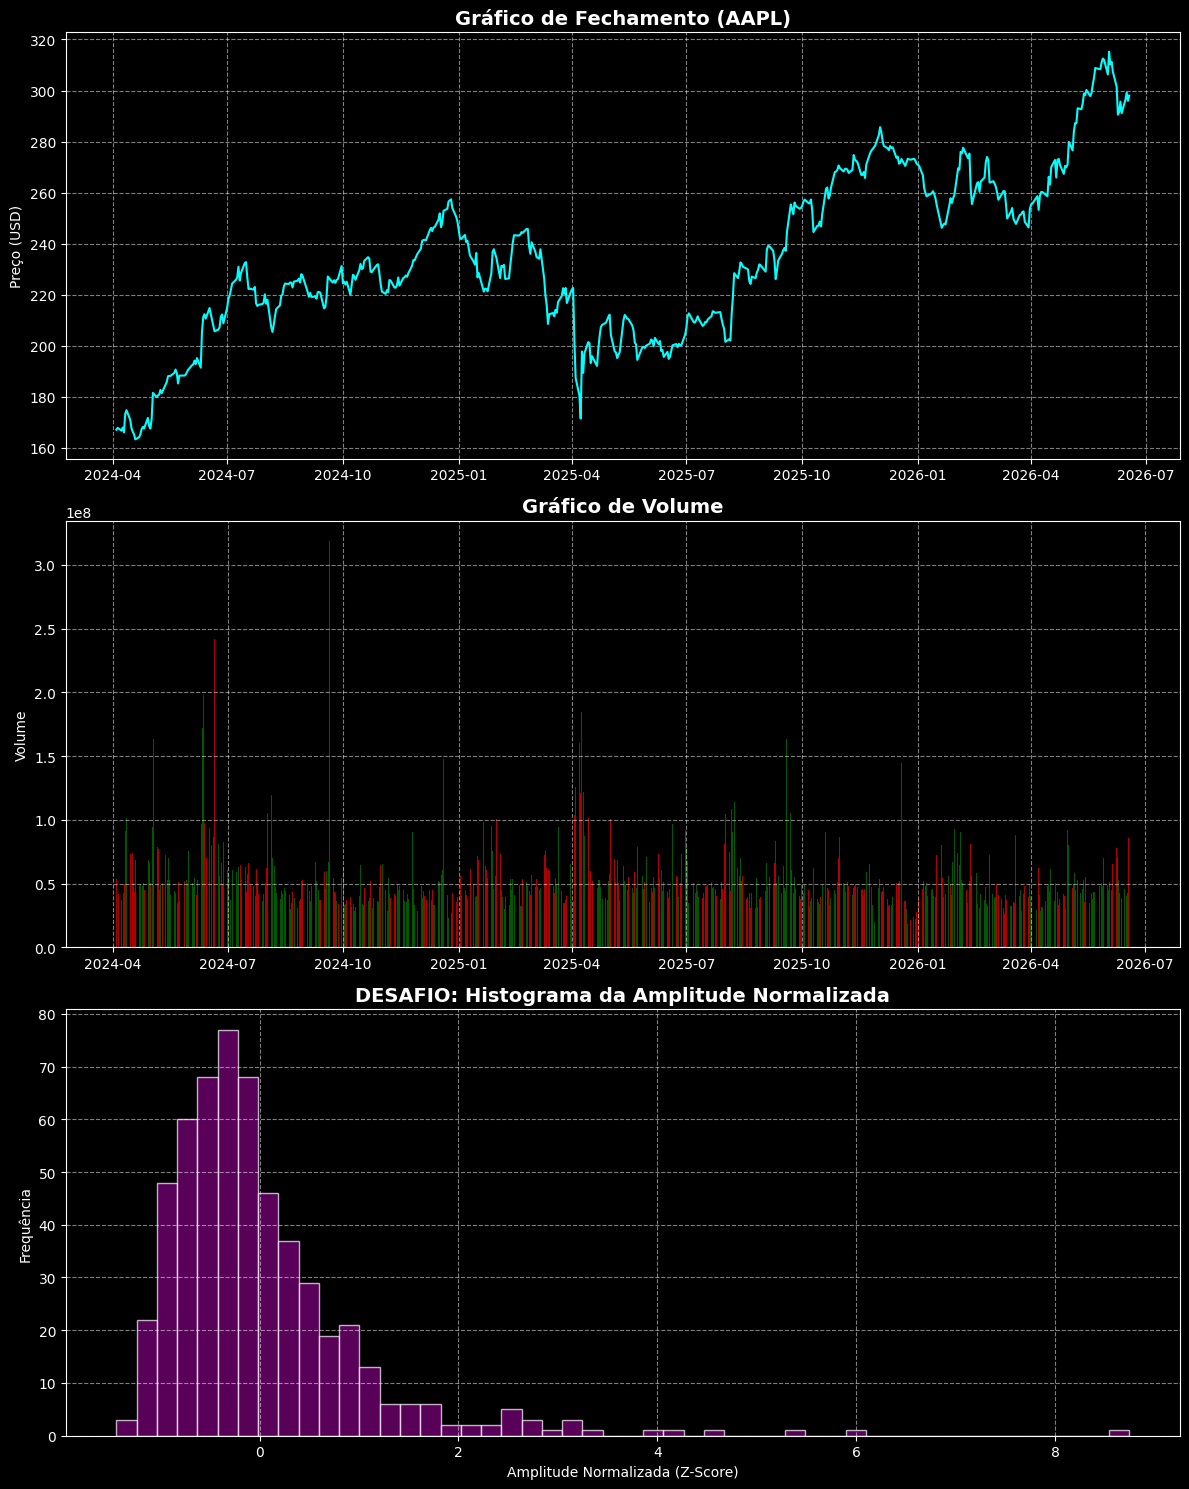

In [ ]:
plt.style.use('dark_background')
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 15))

# 1. Gráfico de Fechamento
ax1.plot(df.index, df['close'], color='cyan', linewidth=1.5)
ax1.set_title('Gráfico de Fechamento (AAPL)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Preço (USD)')
ax1.grid(True, linestyle='--', alpha=0.5)

# 2. Gráfico de Volume
cores_volume = ['green' if df['close'].iloc[i] >= df['open'].iloc[i] else 'red' for i in range(len(df))]
ax2.bar(df.index, df['volume'], color=cores_volume, alpha=0.7)
ax2.set_title('Gráfico de Volume', fontsize=14, fontweight='bold')
ax2.set_ylabel('Volume')
ax2.grid(True, linestyle='--', alpha=0.5)

# 3. DESAFIO: Histograma da Amplitude Normalizada
# Normalizando a amplitude
amplitude_normalizada = (df['amplitude'] - df['amplitude'].mean()) / df['amplitude'].std()
ax3.hist(amplitude_normalizada, bins=50, color='purple', edgecolor='white', alpha=0.7)
ax3.set_title('DESAFIO: Histograma da Amplitude Normalizada', fontsize=14, fontweight='bold')
ax3.set_xlabel('Amplitude Normalizada (Z-Score)')
ax3.set_ylabel('Frequência')
ax3.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

#4. Laborização (Feature Engineering)

In [ ]:
df["Alta_Volatilidade"] = (df["amplitude"] > df["media_Nd"]).astype(int)

contagem = df["Alta_Volatilidade"].value_counts()
n_alta  = int(contagem.get(1, 0))
n_baixa = int(contagem.get(0, 0))
pct_alta = 100 * n_alta / len(df)

print("Distribuição da variável alvo (Y):")
print(f"  Alta Volatilidade  (Y=1): {n_alta:>4d} dias  ({pct_alta:.1f}%)")
print(f"  Baixa Volatilidade (Y=0): {n_baixa:>4d} dias  ({100-pct_alta:.1f}%)")

X = df[features].copy()
Y = df["Alta_Volatilidade"].copy()









Distribuição da variável alvo (Y):
  Alta Volatilidade  (Y=1):  272 dias  (49.1%)
  Baixa Volatilidade (Y=0):  282 dias  (50.9%)


##Divisão Treino / Teste

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.20, random_state=42, shuffle=False
)

print(f"Amostras de treino : {len(X_train)}")
print(f"Amostras de teste  : {len(X_test)}")
print()

_sc = StandardScaler().fit(X_train)
print("StandardScaler — médias aprendidas no TREINO (primeiras 3 colunas):")
for col, mean_, std_ in zip(features[:3], _sc.mean_[:3], _sc.scale_[:3]):
    print(f"  {col:<12} média={mean_:>8.4f}  desvio={std_:>8.4f}")

Amostras de treino : 443
Amostras de teste  : 111

StandardScaler — médias aprendidas no TREINO (primeiras 3 colunas):
  open         média=224.2716  desvio= 26.7728
  high         média=226.7085  desvio= 26.7066
  low          média=222.1108  desvio= 26.6773


##Definição dos 6 Modelos

In [ ]:
modelos = {
    "Gaussian NB":      Pipeline([
        ("scaler", StandardScaler()),
        ("clf",    GaussianNB())
    ]),
    "Decision Tree":    Pipeline([
        ("scaler", StandardScaler()),
        ("clf",    DecisionTreeClassifier(max_depth=4, random_state=42))
    ]),
    "Random Forest":    Pipeline([
        ("scaler", StandardScaler()),
        ("clf",    RandomForestClassifier(n_estimators=100, max_depth=5,
                                          random_state=42, n_jobs=-1))
    ]),
    "SVM":              Pipeline([
        ("scaler", StandardScaler()),
        ("clf",    SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42))
    ]),
    "KNN":              Pipeline([
        ("scaler", StandardScaler()),
        ("clf",    KNeighborsClassifier(n_neighbors=5, metric="minkowski"))
    ]),
    "MLP (Rede Neural)": Pipeline([
        ("scaler", StandardScaler()),
        ("clf",    MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500,
                                 activation="relu", solver="adam",
                                 random_state=42, early_stopping=True,
                                 validation_fraction=0.15, n_iter_no_change=20))
    ]),
}

##Treinamento e Avaliação dos Modelos

In [ ]:
resultados = {}
predicoes  = {}

print("=" * 55)
print(f"  {'Modelo':<22} | Acurácia")
print("─" * 55)

for nome, pipeline in modelos.items():
    pipeline.fit(X_train, Y_train)
    Y_pred       = pipeline.predict(X_test)
    acc          = accuracy_score(Y_test, Y_pred)
    resultados[nome] = acc
    predicoes[nome]  = Y_pred
    print(f"  {nome:<22} | {acc*100:>6.2f}%")

print("=" * 55)
melhor = max(resultados, key=resultados.get)
print(f"\n🏆 Melhor modelo: {melhor}  ({resultados[melhor]*100:.2f}%)")

  Modelo                 | Acurácia
───────────────────────────────────────────────────────
  Gaussian NB            |  88.29%
  Decision Tree          |  84.68%
  Random Forest          |  97.30%
  SVM                    |  88.29%
  KNN                    |  87.39%
  MLP (Rede Neural)      |  92.79%

🏆 Melhor modelo: Random Forest  (97.30%)


##Relatórios de Classificação

In [ ]:
print("\n" + "=" * 55)
print("  RELATÓRIOS DE CLASSIFICAÇÃO")
print("=" * 55)

for nome, Y_pred in predicoes.items():
    print(f"\n── {nome} ──")
    print(classification_report(
        Y_test, Y_pred,
        target_names=["Baixa Volatilidade", "Alta Volatilidade"],
        zero_division=0
    ))



  RELATÓRIOS DE CLASSIFICAÇÃO

── Gaussian NB ──
                    precision    recall  f1-score   support

Baixa Volatilidade       0.79      0.98      0.87        46
 Alta Volatilidade       0.98      0.82      0.89        65

          accuracy                           0.88       111
         macro avg       0.89      0.90      0.88       111
      weighted avg       0.90      0.88      0.88       111


── Decision Tree ──
                    precision    recall  f1-score   support

Baixa Volatilidade       0.75      0.96      0.84        46
 Alta Volatilidade       0.96      0.77      0.85        65

          accuracy                           0.85       111
         macro avg       0.85      0.86      0.85       111
      weighted avg       0.87      0.85      0.85       111


── Random Forest ──
                    precision    recall  f1-score   support

Baixa Volatilidade       0.96      0.98      0.97        46
 Alta Volatilidade       0.98      0.97      0.98        65



##Matrizes de Confusão

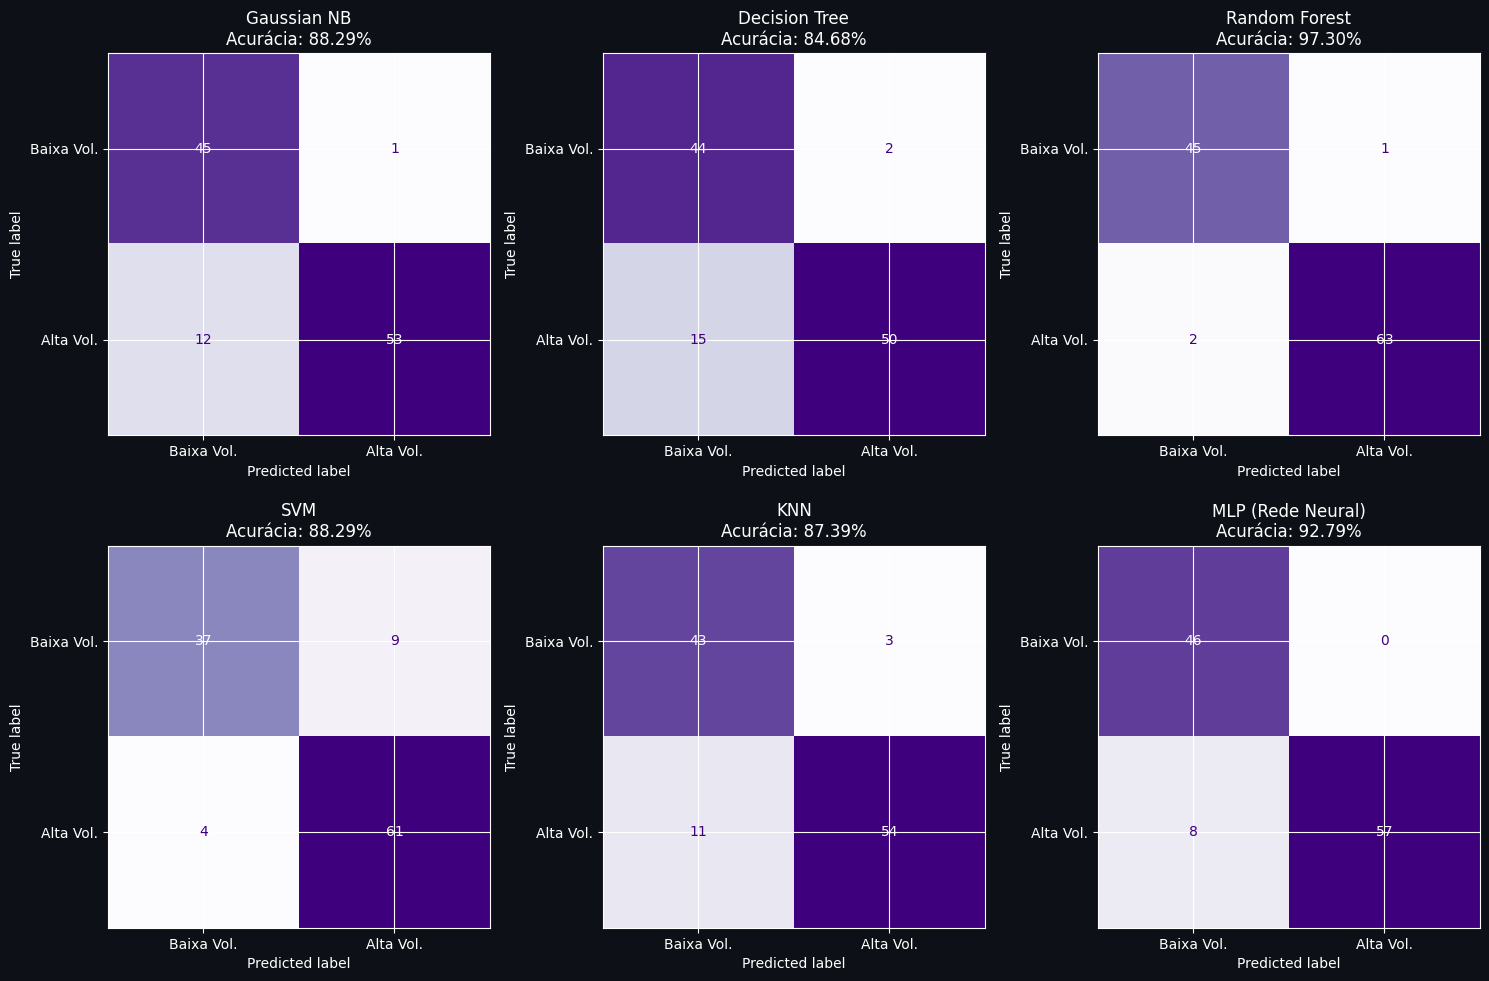

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.patch.set_facecolor('#0d1117')
axes_flat = axes.flatten()

for idx, (nome, Y_pred) in enumerate(predicoes.items()):
    ax = axes_flat[idx]
    ax.set_facecolor('#161b22')
    cm = confusion_matrix(Y_test, Y_pred)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Baixa Vol.", "Alta Vol."]
    )
    disp.plot(ax=ax, cmap="Purples", colorbar=False)
    ax.set_title(f"{nome}\nAcurácia: {resultados[nome]*100:.2f}%", fontsize=12, color='white')
    ax.tick_params(colors='white')
    ax.xaxis.label.set_color('white')
    ax.yaxis.label.set_color('white')

plt.tight_layout()
plt.show()